# Phase 4: Model Implementation - 1D Convolutional Neural Network (CNN)

Pada notebook ini kita akan membangun, melatih, dan mengevaluasi model **1D-CNN**. 
CNN sangat baik dalam mengekstraksi fitur lokal (motif spasial berdekatan) pada sekuens asam amino yang menandakan fungsi spesifik sebuah protein.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, matthews_corrcoef
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import json

# Set device ke CUDA jika tersedia
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Menggunakan device: {device}")

os.makedirs('models', exist_ok=True)
os.makedirs('data/results', exist_ok=True)

Menggunakan device: cuda


In [2]:
# 1. Load Dataset
train_df = pd.read_csv('data/processed/train.csv')
test_df = pd.read_csv('data/processed/test.csv')

with open('data/processed/label_mapping.json', 'r') as f:
    label_mapping = json.load(f)

num_classes = len(label_mapping)
print(f"Data Train: {len(train_df)}, Data Test: {len(test_df)}, Jumlah Kelas: {num_classes}")

Data Train: 20073, Data Test: 5019, Jumlah Kelas: 6


In [3]:
# 2. Konfigurasi Tokenisasi (Asam Amino ke Integer)
# Standar 20 Asam amino
amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
aa_to_int = {aa: i+1 for i, aa in enumerate(amino_acids)}
aa_to_int['<PAD>'] = 0
VOCAB_SIZE = len(aa_to_int)

class ProteinDataset(Dataset):
    def __init__(self, sequences, labels, max_len=1000):
        self.sequences = sequences
        self.labels = labels
        self.max_len = max_len
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        seq = self.sequences.iloc[idx]
        label = self.labels.iloc[idx]
        
        # Ubah karakter menjadi integer
        seq_int = [aa_to_int.get(aa, 0) for aa in seq[:self.max_len]]
        
        # Padding
        if len(seq_int) < self.max_len:
            seq_int += [0] * (self.max_len - len(seq_int))
            
        return torch.tensor(seq_int, dtype=torch.long), torch.tensor(label, dtype=torch.long)

MAX_LEN = 1000
BATCH_SIZE = 64 # Cocok untuk VRAM 4GB

train_dataset = ProteinDataset(train_df['Sequence'], train_df['Label'], max_len=MAX_LEN)
test_dataset = ProteinDataset(test_df['Sequence'], test_df['Label'], max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print("DataLoader siap.")

DataLoader siap.


In [4]:
# 3. Definisi Arsitektur Multi-Scale 1D-CNN
class ProteinMultiScaleCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super(ProteinMultiScaleCNN, self).__init__()
        # Layer Embedding
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.spatial_dropout = nn.Dropout1d(p=0.3)
        
        # Branch 1: Kernel 3
        self.branch1 = nn.Sequential(
            nn.Conv1d(in_channels=embed_dim, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128)
        )
        # Branch 2: Kernel 5
        self.branch2 = nn.Sequential(
            nn.Conv1d(in_channels=embed_dim, out_channels=128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(128)
        )
        # Branch 3: Kernel 9
        self.branch3 = nn.Sequential(
            nn.Conv1d(in_channels=embed_dim, out_channels=128, kernel_size=9, padding=4),
            nn.ReLU(),
            nn.BatchNorm1d(128)
        )
        
        # Global Pooling (Max + Avg)
        self.global_max_pool = nn.AdaptiveMaxPool1d(1)
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        
        # Fully Connected Layer
        self.fc = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.embedding(x)             # [batch_size, seq_len, embed_dim]
        x = x.transpose(1, 2)             # [batch_size, embed_dim, seq_len]
        
        x = self.spatial_dropout(x)
        
        out1 = self.branch1(x)            
        out2 = self.branch2(x)            
        out3 = self.branch3(x)            
        
        max1 = self.global_max_pool(out1).squeeze(-1) 
        avg1 = self.global_avg_pool(out1).squeeze(-1) 
        
        max2 = self.global_max_pool(out2).squeeze(-1)
        avg2 = self.global_avg_pool(out2).squeeze(-1)
        
        max3 = self.global_max_pool(out3).squeeze(-1)
        avg3 = self.global_avg_pool(out3).squeeze(-1)
        
        pooled = torch.cat([max1, avg1, max2, avg2, max3, avg3], dim=1) 
        
        out = self.fc(pooled)             
        return out

EMBED_DIM = 64
model = ProteinMultiScaleCNN(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, num_classes=num_classes).to(device)
print(model)

ProteinMultiScaleCNN(
  (embedding): Embedding(21, 64, padding_idx=0)
  (spatial_dropout): Dropout1d(p=0.3, inplace=False)
  (branch1): Sequential(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (branch2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (branch3): Sequential(
    (0): Conv1d(64, 128, kernel_size=(9,), stride=(1,), padding=(4,))
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (global_max_pool): AdaptiveMaxPool1d(output_size=1)
  (global_avg_pool): AdaptiveAvgPool1d(output_size=1)
  (fc): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5,

In [5]:
# 4. Konfigurasi Pelatihan dengan Optimasi
from sklearn.utils.class_weight import compute_class_weight

# Menghitung Class Weights
labels_array = train_df['Label'].values
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels_array), y=labels_array)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Weight Decay ditambahkan ke optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# ReduceLROnPlateau Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

EPOCHS = 50
PATIENCE = 5
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

best_val_loss = float('inf')
best_epoch = 0
epochs_no_improve = 0
early_stop_triggered = False
best_model_path = 'models/cnn_model_best.pth'

print("\nMemulai proses pelatihan...")
for epoch in range(EPOCHS):
    start_time = time.time()
    
    # --- FASE TRAINING ---
    model.train()
    train_loss, correct, total = 0.0, 0, 0
    for seqs, labels in train_loader:
        seqs, labels = seqs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(seqs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * seqs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    epoch_train_loss = train_loss / total
    epoch_train_acc = correct / total
    
    # --- FASE VALIDATION (TESTING) ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for seqs, labels in test_loader:
            seqs, labels = seqs.to(device), labels.to(device)
            outputs = model(seqs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * seqs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)
            
    epoch_val_loss = val_loss / total_val
    epoch_val_acc = correct_val / total_val
    
    # Step scheduler
    scheduler.step(epoch_val_loss)
    
    # Menyimpan history
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    elapsed_time = time.time() - start_time
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Waktu: {elapsed_time:.0f}s | LR: {current_lr:.6f} | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_epoch = epoch + 1
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\n[Early Stopping Triggered] No improvement for {PATIENCE} consecutive epochs.")
            early_stop_triggered = True
            break

print("\n--- Training Summary ---")
print(f"Early Stopping Triggered: {early_stop_triggered}")
print(f"Total Epochs Run: {epoch + 1}")
print(f"Best Epoch: {best_epoch} (Val Loss: {best_val_loss:.4f})")
model.load_state_dict(torch.load(best_model_path))
print("Best model weights loaded.")


Memulai proses pelatihan...
Epoch 01/50 | Waktu: 145s | LR: 0.001000 | Train Loss: 1.4674 Acc: 0.3828 | Val Loss: 0.9672 Acc: 0.5828
Epoch 02/50 | Waktu: 146s | LR: 0.001000 | Train Loss: 1.0479 Acc: 0.5500 | Val Loss: 0.8466 Acc: 0.6376
Epoch 03/50 | Waktu: 145s | LR: 0.001000 | Train Loss: 0.9529 Acc: 0.5966 | Val Loss: 0.7984 Acc: 0.6914
Epoch 04/50 | Waktu: 142s | LR: 0.001000 | Train Loss: 0.9022 Acc: 0.6248 | Val Loss: 0.7129 Acc: 0.7183
Epoch 05/50 | Waktu: 142s | LR: 0.001000 | Train Loss: 0.8533 Acc: 0.6440 | Val Loss: 0.6672 Acc: 0.7167
Epoch 06/50 | Waktu: 141s | LR: 0.001000 | Train Loss: 0.8144 Acc: 0.6650 | Val Loss: 0.6445 Acc: 0.7402
Epoch 07/50 | Waktu: 135s | LR: 0.001000 | Train Loss: 0.8016 Acc: 0.6756 | Val Loss: 0.6399 Acc: 0.7509
Epoch 08/50 | Waktu: 128s | LR: 0.001000 | Train Loss: 0.7632 Acc: 0.6875 | Val Loss: 0.6335 Acc: 0.7547
Epoch 09/50 | Waktu: 128s | LR: 0.001000 | Train Loss: 0.7509 Acc: 0.6989 | Val Loss: 0.6033 Acc: 0.7625
Epoch 10/50 | Waktu: 128s 


--- Classification Report ---
                      precision    recall  f1-score   support

                GPCR       0.98      0.95      0.96       664
           Hydrolase       0.59      0.73      0.65       857
         Ion Channel       0.94      0.93      0.94       894
              Kinase       0.92      0.82      0.87       837
      Oxidoreductase       0.80      0.80      0.80       906
Transcription Factor       0.88      0.80      0.83       861

            accuracy                           0.84      5019
           macro avg       0.85      0.84      0.84      5019
        weighted avg       0.85      0.84      0.84      5019


MCC Score: 0.8026


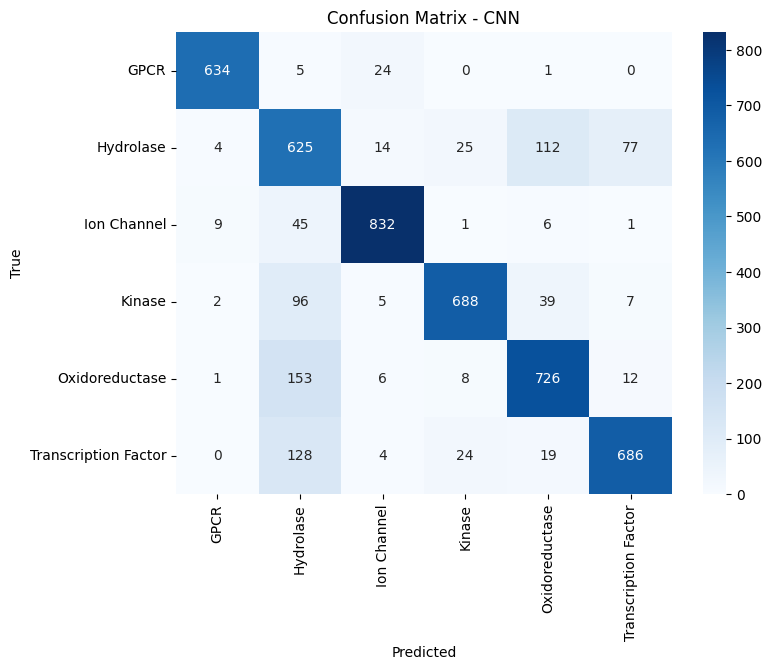

Model dan hasil evaluasi berhasil disimpan.


In [6]:
# 5. Evaluasi Metrik Lebih Lanjut dan Simpan Model
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for seqs, labels in test_loader:
        seqs = seqs.to(device)
        outputs = model(seqs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n--- Classification Report ---")
class_names = [label_mapping[str(i)] for i in range(num_classes)]
report = classification_report(all_labels, all_preds, target_names=class_names)
print(report)

mcc = matthews_corrcoef(all_labels, all_preds)
print(f"\nMCC Score: {mcc:.4f}")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - CNN')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Simpan metrik performa ke sebuah file agar bisa dibandingkan nanti
results = {
    'accuracy': accuracy_score(all_labels, all_preds),
    'f1_macro': f1_score(all_labels, all_preds, average='macro'),
    'mcc': mcc,
    'history': history
}
with open('data/results/cnn_metrics.json', 'w') as f:
    json.dump(results, f)

# Simpan bobot (weights) model
torch.save(model.state_dict(), 'models/cnn_model.pth')
print("Model dan hasil evaluasi berhasil disimpan.")

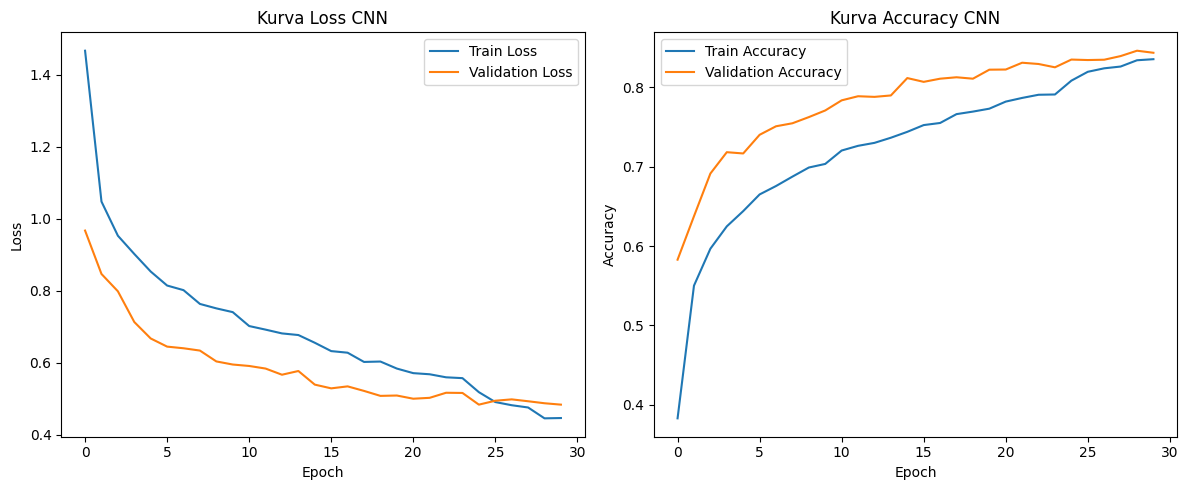

In [7]:
# Visualisasi Kurva Loss & Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Kurva Loss CNN')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Kurva Accuracy CNN')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()